# Section 1: Imports and setup
<a id="1"></a>

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from scipy.stats import gaussian_kde
import shap

print("All libraries loaded successfully")


All libraries loaded successfully


# Section 2: Dataset gathering

#### dataset link: "<a href="https://zenodo.org/records/1323611">Condition monitoring Data Set at ZeMA</a>"
<a id="2"></a>

In [27]:
np.random.seed(42)
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'fuel_flow': pd.read_csv("/kaggle/input/datasets/garvpatel/data-set-at-zema/FS1.txt", sep=r"\s+", header=None).mean(axis=1),
    'fuel_pressure': pd.read_csv("/kaggle/input/datasets/garvpatel/data-set-at-zema/PS2.txt", sep=r"\s+", header=None).mean(axis=1),
    'hydraulic_pressure': pd.read_csv("/kaggle/input/datasets/garvpatel/data-set-at-zema/PS5.txt", sep=r"\s+", header=None).mean(axis=1),
    'hydraulic_temp': pd.read_csv("/kaggle/input/datasets/garvpatel/data-set-at-zema/TS3.txt", sep=r"\s+", header=None).mean(axis=1)
})

np.random.seed(42)
df['fault'] = 0
df.loc[np.random.choice(df.index, int(len(df) * 0.05), replace=False), 'fault'] = 1

df.to_csv("aircraft_sensor_dataset.csv", index=False)
print(df.head())
print(df.shape)
print(df.describe().round(2))

   fuel_flow  fuel_pressure  hydraulic_pressure  hydraulic_temp  fault
0   6.709815     109.466914            9.842170       38.471017      0
1   6.715315     109.354890            9.635142       38.978967      0
2   6.718522     109.158845            9.530548       39.631950      0
3   6.720565     109.064807            9.438827       40.403383      0
4   6.690308     108.931434            9.358762       41.310550      0
(2205, 5)
       fuel_flow  fuel_pressure  hydraulic_pressure  hydraulic_temp    fault
count    2205.00        2205.00             2205.00         2205.00  2205.00
mean        6.20         109.38                9.16           47.66     0.05
std         1.03           4.99                0.58            7.45     0.22
min         2.02         104.41                8.37           38.25     0.00
25%         6.39         106.96                8.55           39.12     0.00
50%         6.58         107.73                9.12           47.07     0.00
75%         6.66         

# Section 3: Feature engineering
<a id="3"></a>

In [28]:
df['fuel_flow_mean5']  = df['fuel_flow'].rolling(5).mean()
df['fuel_flow_std5']   = df['fuel_flow'].rolling(5).std()
df['hyd_temp_lag1']    = df['hydraulic_temp'].shift(1)
df['hyd_press_delta']  = df['hydraulic_pressure'].diff()

df = df.dropna().reset_index(drop=True)
print(f"Dataset shape after features: {df.shape}")
print(df.head(3))

Dataset shape after features: (2201, 9)
   fuel_flow  fuel_pressure  hydraulic_pressure  hydraulic_temp  fault  \
0   6.690308     108.931434            9.358762       41.310550      0   
1   6.699023     108.887682            9.301160       42.124117      0   
2   6.698573     108.676466            9.233942       42.888117      0   

   fuel_flow_mean5  fuel_flow_std5  hyd_temp_lag1  hyd_press_delta  
0         6.710905        0.012208      40.403383        -0.080065  
1         6.708747        0.013350      41.310550        -0.057602  
2         6.705398        0.013390      42.124117        -0.067218  


# Section 4: Model training — Isolation Forest
<a id="4"></a>

In [31]:
feature_cols = ['fuel_flow','fuel_pressure','hydraulic_pressure',
                'hydraulic_temp','fuel_flow_mean5','hyd_press_delta']
X_raw = df[feature_cols]
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Model 1 — Isolation Forest
iforest = IsolationForest(contamination=0.05, random_state=42)
pred_if = iforest.fit_predict(X)


# Section 5: Model training — One-Class SVM
<a id="5"></a>

In [32]:
# Model 2 — One-Class SVM
ocsvm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
pred_svm = ocsvm.fit_predict(X)


# Section 6: Model training — KDE
<a id="6"></a>

In [34]:
# Model 3 — KDE on fuel flow
kde = gaussian_kde(df['fuel_flow'])
kde_scores = kde(df['fuel_flow'])
threshold = np.percentile(kde_scores, 5)
pred_kde = np.where(kde_scores < threshold, -1, 1)

print("Models trained")
print(f"IF anomalies: {(pred_if==-1).sum()}")
print(f"SVM anomalies: {(pred_svm==-1).sum()}")
print(f"KDE anomalies: {(pred_kde==-1).sum()}")

Models trained
IF anomalies: 110
SVM anomalies: 109
KDE anomalies: 110


# Section 7: Ensemble voting
<a id="7"></a>

In [36]:
votes = ((pred_if  == -1).astype(int) +
         (pred_svm == -1).astype(int) +
         (pred_kde == -1).astype(int))

df['anomaly']  = (votes >= 2).astype(int)
df['severity'] = votes * 33

def get_state(row):
    if row['severity'] == 0:   return 'NORMAL'
    if row['severity'] <= 33:  return 'ADVISORY'
    return 'WARNING'

df['state'] = df.apply(get_state, axis=1)

print(df['state'].value_counts())
print(f"Anomaly rate: {df['anomaly'].mean()*100:.1f}%")

state
NORMAL      1984
ADVISORY     134
WARNING       83
Name: count, dtype: int64
Anomaly rate: 3.8%


# Section 8: SHAP explainability
<a id="8"></a>

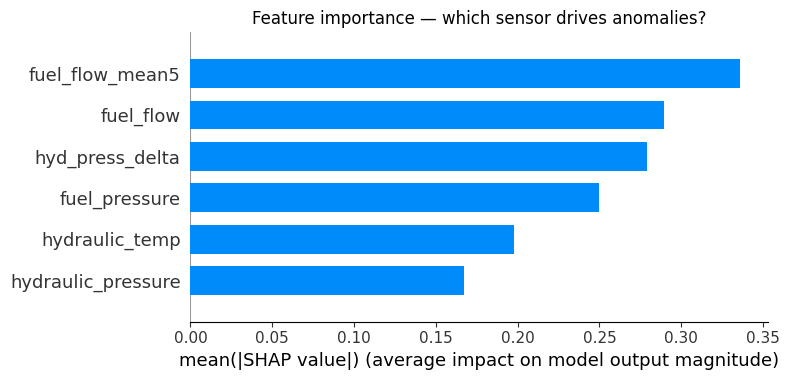

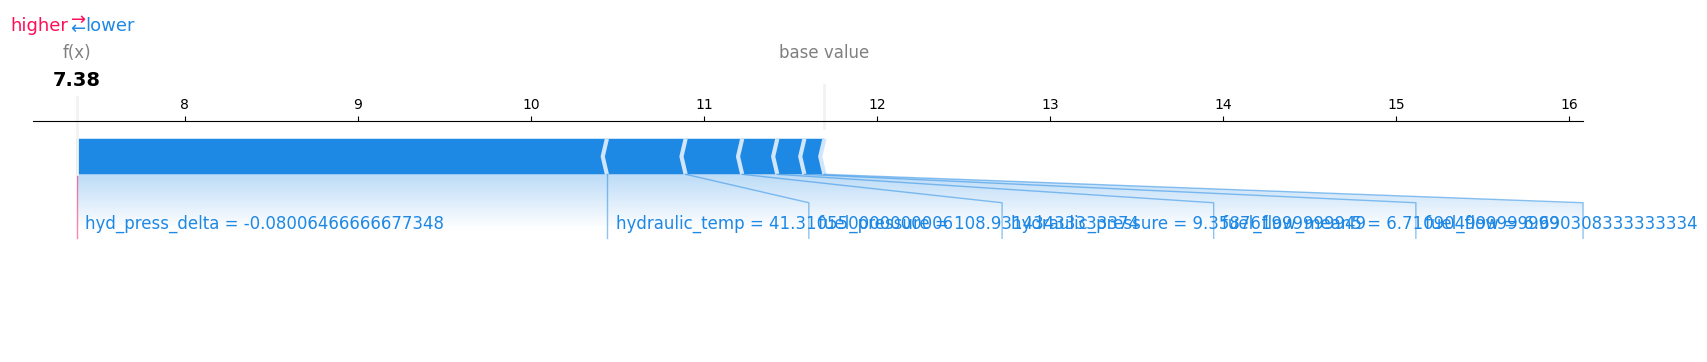

In [38]:
explainer = shap.TreeExplainer(iforest)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values, X_raw,
    plot_type="bar",
    show=False
)
plt.title("Feature importance — which sensor drives anomalies?")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

warning_rows = df[df['state'] == 'WARNING'].head(1)
idx = warning_rows.index[0]
X_single = X[idx:idx+1]

shap.force_plot(
    explainer.expected_value,
    explainer.shap_values(X_single)[0],
    X_raw.iloc[idx],
    matplotlib=True,
    show=False
)
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 9: Dashboard visualization
<a id="9"></a>

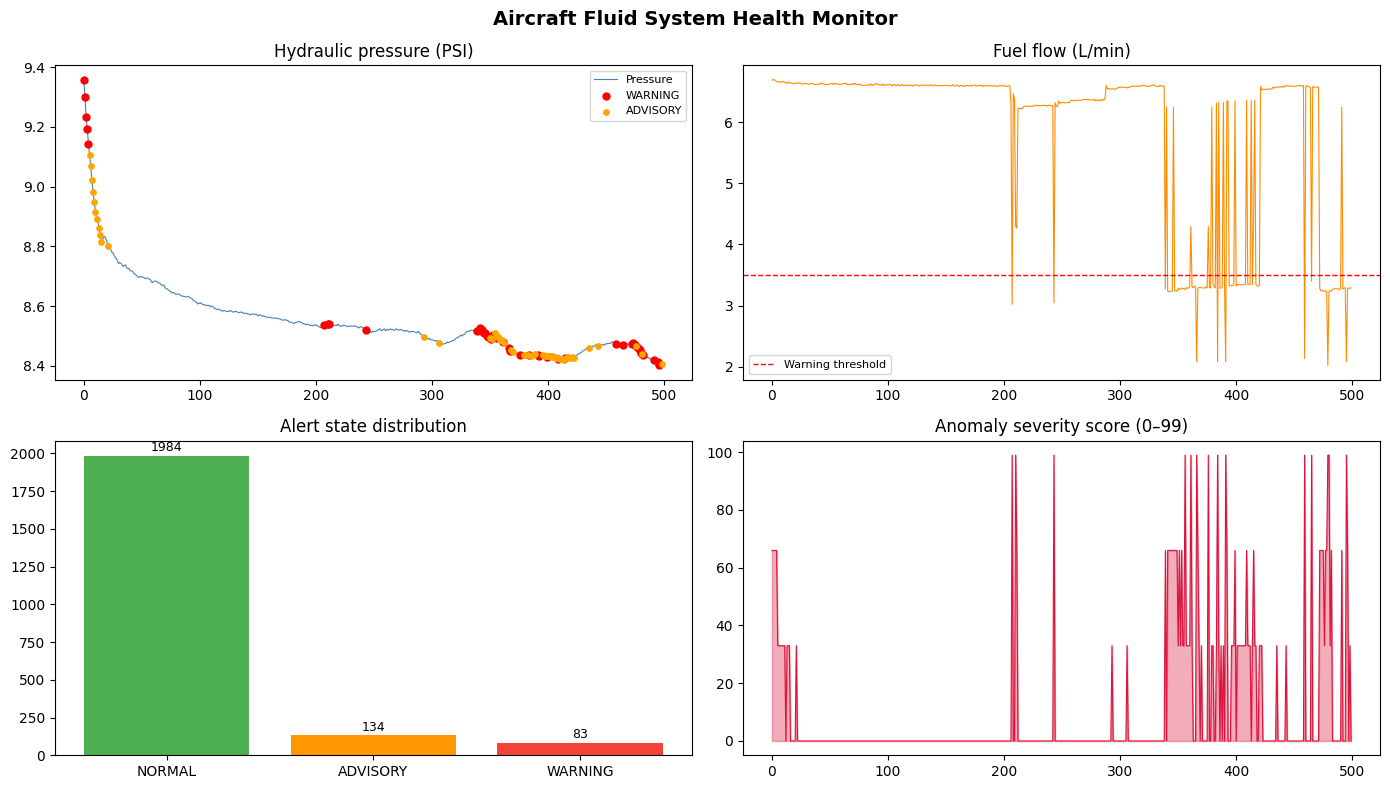

In [40]:
sample = df.head(500).reset_index(drop=True)
t = range(len(sample))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Aircraft Fluid System Health Monitor',
             fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.plot(t, sample['hydraulic_pressure'], color='steelblue', lw=0.8, label='Pressure')
w = sample[sample['state']=='WARNING']
a = sample[sample['state']=='ADVISORY']
ax.scatter(w.index, w['hydraulic_pressure'], color='red',    s=25, zorder=5, label='WARNING')
ax.scatter(a.index, a['hydraulic_pressure'], color='orange', s=15, zorder=5, label='ADVISORY')
ax.set_title('Hydraulic pressure (PSI)')
ax.legend(fontsize=8)

ax = axes[0,1]
ax.plot(t, sample['fuel_flow'], color='darkorange', lw=0.8)
ax.axhline(y=3.5, color='red', linestyle='--', lw=1, label='Warning threshold')
ax.set_title('Fuel flow (L/min)')
ax.legend(fontsize=8)

ax = axes[1,0]
counts = df['state'].value_counts()
colors_map = {'NORMAL':'#4CAF50','ADVISORY':'#FF9800','WARNING':'#F44336'}
ax.bar(counts.index, counts.values,
       color=[colors_map[s] for s in counts.index])
ax.set_title('Alert state distribution')
for i, (s, v) in enumerate(counts.items()):
    ax.text(i, v + 30, str(v), ha='center', fontsize=9)

ax = axes[1,1]
ax.fill_between(range(len(sample)), sample['severity'], alpha=0.35, color='crimson')
ax.plot(range(len(sample)), sample['severity'], color='crimson', lw=0.8)
ax.set_title('Anomaly severity score (0–99)')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 10: Evaluation metrics
<a id="10"></a>

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96      2097
     Anomaly       0.02      0.02      0.02       104

    accuracy                           0.92      2201
   macro avg       0.49      0.49      0.49      2201
weighted avg       0.91      0.92      0.91      2201



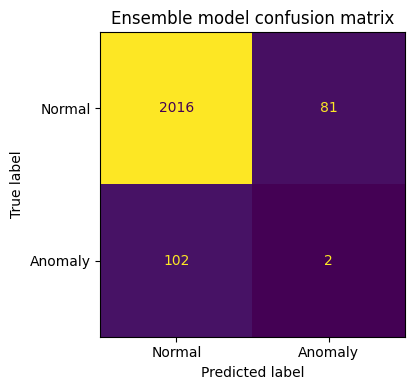

In [41]:
y_true = np.zeros(len(df))
true_faults = [i for i in fault_idx if i < len(df)]
y_true[true_faults] = 1

y_pred = df['anomaly'].values

print("=== Classification Report ===")
print(classification_report(y_true, y_pred,
      target_names=['Normal', 'Anomaly']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=['Normal', 'Anomaly'],
    colorbar=False, ax=ax
)
ax.set_title('Ensemble model confusion matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
